# Out-of-Memory Preprocessing with Rust Backend (anndataoom)

This tutorial demonstrates omicverse's **Rust-backed out-of-memory** path (`AnnDataOOM`) for preprocessing scRNA-seq without loading the full expression matrix into memory.

The expression matrix stays on disk (HDF5, via the [anndataoom](https://pypi.org/project/anndataoom/) package, which wraps [scverse/anndata-rs](https://github.com/scverse/anndata-rs)). All operations — QC, normalization, HVG selection, scaling, PCA — use **chunked iteration** or **lazy transforms**.

**Install:**

```bash
pip install omicverse[rust]
# or just the backend
pip install anndataoom
```


In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil, os, time, gc

ov.plot_set()

process = psutil.Process(os.getpid())
def mem_mb():
    gc.collect()
    return process.memory_info().rss / 1024**2

mem_log = []
time_log = {}
def snap(label):
    m = mem_mb()
    mem_log.append({'step': label, 'mem_mb': m})
    print(f"  [{label}] RSS = {m:.0f} MB")

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Download PBMC 8k dataset

We'll use the PBMC 8k dataset from 10x Genomics (7750 cells × 20939 genes).

In [2]:
h5ad_path = './data/pbmc8k.h5ad'

if not os.path.exists(h5ad_path):
    print('Downloading PBMC 8k...')
    os.makedirs('./data', exist_ok=True)
    adata_init = ov.datasets.pbmc8k()
    adata_init.write(h5ad_path)
    print(f'Saved to {h5ad_path} ({os.path.getsize(h5ad_path)/1024/1024:.1f} MB)')
    del adata_init
    gc.collect()
else:
    print(f'Dataset already exists: {h5ad_path}')

Dataset already exists: ./data/pbmc8k.h5ad


## 2. Read with Rust backend

`ov.read(path, backend='rust')` returns `AnnDataOOM` — expression matrix stays on disk.

In [3]:
snap('baseline')

t0 = time.time()
adata = ov.read(h5ad_path, backend='rust')
time_log['read'] = time.time() - t0
snap('after read')
print(adata)

  [baseline] RSS = 646 MB
📂 Reading with anndata-rs (Rust · out-of-memory)
   ./data/pbmc8k.h5ad  (39.5 MB)
   ✓ Loaded in 0.17s

💡 Data stays on disk. Use ov.pp.* for chunked processing.
   adata.close() when done · adata.to_adata() to materialise


  [after read] RSS = 719 MB


╭────────────────────────────────────────────────────────────────────────╮
│ AnnDataOOM                               Rust · out-of-memory · backed │
├────────────────────────────────────────────────────────────────────────┤
│                                                                        │
│    7,750   ×   20,939                                                  │
│    obs          vars                                                   │
│                                                                        │
│    csr_matrix · float32 · 9.9% density · ~15.8 MB/chunk (1,000 rows) · │
│    pbmc8k.h5ad                                                         │
│                                                                        │
├────────────────────────────────────────────────────────────────────────┤
│ ▸ obs    (21)   kit · tissue_ontology_term_id · tissue_type  +18       │
│ ▸ var    (6)    gene_name · feature_name · feature_reference  +3       │
│ ▸ obsm   (3)    X_umap 

### AnnDataOOM API compatibility test

In [4]:
# Properties
print(f"shape:      {adata.shape}")
print(f"n_obs:      {adata.n_obs}")
print(f"n_vars:     {adata.n_vars}")
print(f"is_view:    {adata.is_view}")
print(f"isbacked:   {adata.isbacked}")
print(f"obs_keys:   {adata.obs_keys()[:5]}...")
print(f"var_keys:   {adata.var_keys()[:3]}...")

shape:      (7750, 20939)
n_obs:      7750
n_vars:     20939
is_view:    False
isbacked:   True
obs_keys:   ['kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id']...
var_keys:   ['gene_name', 'feature_name', 'feature_reference']...


In [5]:
# obs / var are pandas DataFrames
adata.obs.head()

                                      kit tissue_ontology_term_id tissue_type  \
obs_names                                                                       
TGAGCCGTCGATAGAA-1_10X_5-rep1  10X_5-rep1          UBERON:0000178      tissue   
TACACGACAGGACGTA-1_10X_5-rep1  10X_5-rep1          UBERON:0000178      tissue   
GAAGCAGCAGCTGTGC-1_10X_5-rep1  10X_5-rep1          UBERON:0000178      tissue   
CTCACACAGAGCCCAA-1_10X_5-rep1  10X_5-rep1          UBERON:0000178      tissue   
CTCGTCAGTGATAAAC-1_10X_5-rep1  10X_5-rep1          UBERON:0000178      tissue   

                              assay_ontology_term_id disease_ontology_term_id  \
obs_names                                                                       
TGAGCCGTCGATAGAA-1_10X_5-rep1            EFO:0009900             PATO:0000461   
TACACGACAGGACGTA-1_10X_5-rep1            EFO:0009900             PATO:0000461   
GAAGCAGCAGCTGTGC-1_10X_5-rep1            EFO:0009900             PATO:0000461   
CTCACACAGAGCCCAA-1_10X_5-re

In [6]:
# Subsetting: slice / bool / gene name / gene list
print(f"adata[0:5]:              {adata[0:5].shape}")
print(f"adata[:, 0:3]:           {adata[:, 0:3].shape}")

gene = adata.var_names[10]
print(f"adata[:, '{gene}']: {adata[:, gene].shape}")

genes = list(adata.var_names[:3])
print(f"adata[:, 3-genes]:       {adata[:, genes].shape}")

# obs_vector — single gene expression
g = adata.var_names[0]
print(f"obs_vector('{g}'): {adata.obs_vector(g).shape}")

adata[0:5]:              (5, 20939)
adata[:, 0:3]:           (7750, 3)
adata[:, 'AL645608.7']: (7750, 1)
adata[:, 3-genes]:       (7750, 3)


obs_vector('AL627309.5'): (7750,)


## 3. QC (chunked)

Quality control metrics (nUMIs, detected_genes, mito%) computed via **chunked row iteration**.

In [7]:
t0 = time.time()
adata = ov.pp.qc(
    adata,
    tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
    doublets=False,
)
time_log['qc'] = time.time() - t0
snap('after QC')
print(f"Shape: {adata.shape}, Time: {time_log['qc']:.1f}s")

🖥️ Using CPU mode for QC (out-of-memory)...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 99                 │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 7                  │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘



   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ nUMIs                   │ 5454               │ 497 - 34434             │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ Detected Genes          │ 2071               │ 35 - 6427               │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ Mitochondrial %         │ 2.9%               │ 0.0% - 97.2%            │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ Ribosomal %             │ 20.4%              │ 0.1% - 52.8%            │
   ├─────────────────────────┼────────────────────┼─────────────────────────┤
   │ Hemoglobin %            │ 0.0%               │ 0.0% - 0.3%             │
   └─────────────────────────┴────────

   ✓ Final filtering: 0 cells, 10 genes removed

📊 Step 4: Doublet detection disabled

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 3.4325s                                                 │
│  Shape:    7,750 x 20,939 -> 7,698 x 20,929                        │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ passing_mt (bool)                                    │
│           │ ✚ passing_nUMIs (bool)                         

  [after QC] RSS = 746 MB
Shape: (7698, 20929), Time: 3.6s


## 4. Preprocess (lazy normalize + log1p + chunked HVG)

In [8]:
t0 = time.time()
adata = ov.pp.preprocess(
    adata, mode='shiftlog|pearson',
    n_HVGs=2000, target_sum=50*1e4,
)
time_log['preprocess'] = time.time() - t0
snap('after preprocess')
print(f"Shape: {adata.shape}, Time: {time_log['preprocess']:.1f}s")

🔍 [2026-04-16 21:51:23] Running preprocessing in 'cpu' mode...
Begin robust gene identification


✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson


    Time to analyze data (out-of-memory): 6.94 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ──────────────────────────────────────────────╮
│  Duration: 7.703s                                                  │
│  Shape:    7,698 x 20,929 -> 7,698 x 20,064                        │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ _norm_factor (float)                                 │
│                                                                    │
│

  [after preprocess] RSS = 746 MB
Shape: (7698, 20064), Time: 7.7s


## 5. HVG + Scale (lazy) + PCA (chunked randomized SVD)

In [9]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
print(f'After HVG subset: {adata.shape}')
snap('after HVG subset')

t0 = time.time()
ov.pp.scale(adata)
time_log['scale'] = time.time() - t0

from anndataoom import ScaledBackedArray
print(f"Scale is lazy: {isinstance(adata.layers['scaled'], ScaledBackedArray)}")
snap('after scale')

t0 = time.time()
ov.pp.pca(adata, layer='scaled', n_pcs=50)
time_log['pca'] = time.time() - t0
snap('after PCA')
print(f"Shape: {adata.shape}, PCA: {adata.obsm['X_pca'].shape}")

After HVG subset: (7698, 2000)
  [after HVG subset] RSS = 746 MB



╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 3.3522s                                                 │
│  Shape:    7,698 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (ScaledBackedArray)                           │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
Scale is lazy: True
  [after scale] RSS = 758 MB
computing PCA🔍
    with n_comps=50



╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 35.4071s                                                │
│  Shape:    7,698 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 7698x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


  [after PCA] RSS = 816 MB
Shape: (7698, 2000), PCA: (7698, 50)


## 6. Neighbors + UMAP + Leiden

In [10]:
t0 = time.time()
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
                use_rep='scaled|original|X_pca')
time_log['neighbors'] = time.time() - t0

t0 = time.time()
ov.pp.umap(adata)
time_log['umap'] = time.time() - t0

t0 = time.time()
ov.pp.leiden(adata, resolution=1)
time_log['leiden'] = time.time() - t0
snap('after clustering')
print(f"Clusters: {adata.obs['leiden'].nunique()}")

🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: scaled|original|X_pca
   PCs used: 50
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 7,698 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.3894s                                                 │
│  Shape:    7,698 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 7,698 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 2.8294s                                                 │
│  Shape:    7,698 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CP

    finished (0.44s)
    found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 0.4449s                                                 │
│  Shape:    7,698 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ leiden (category)                                    │
│                                                                    │
│  ● UNS    │ ✚ leiden                                               │
│           │ └─ params: {'resolution': 1, 'random_state': 0, 'n_iterati...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


  [after clustering] RSS = 916 MB
Clusters: 19


## 7. Visualization (all ov.pl, use_raw supported)

All omicverse plotting functions work natively with `AnnDataOOM`.

In [11]:
hvg_gene = adata.var_names[0]
non_hvg_genes = list(set(adata.raw.var_names) - set(adata.var_names))[:3]
print(f'HVG gene: {hvg_gene}')
print(f'Non-HVG genes (raw only): {non_hvg_genes}')

HVG gene: HES4
Non-HVG genes (raw only): ['THADA', 'DPP10', 'AC012511.2']


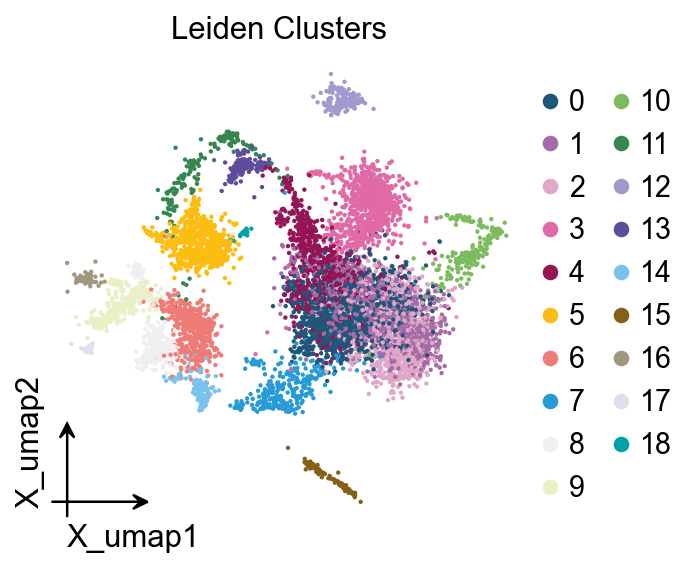

In [12]:
# Leiden clusters
ov.pl.embedding(adata, basis='X_umap', color='leiden',
                frameon='small', title='Leiden Clusters')

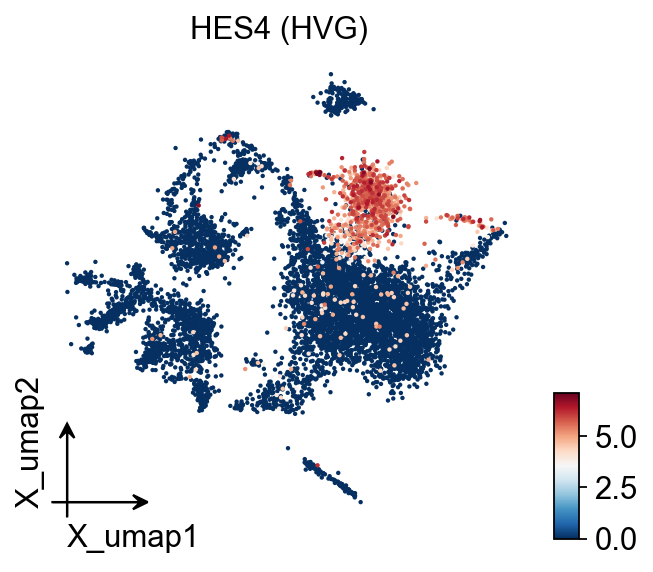

In [13]:
# Gene expression (HVG)
ov.pl.embedding(adata, basis='X_umap', color=hvg_gene,
                frameon='small', title=f'{hvg_gene} (HVG)')

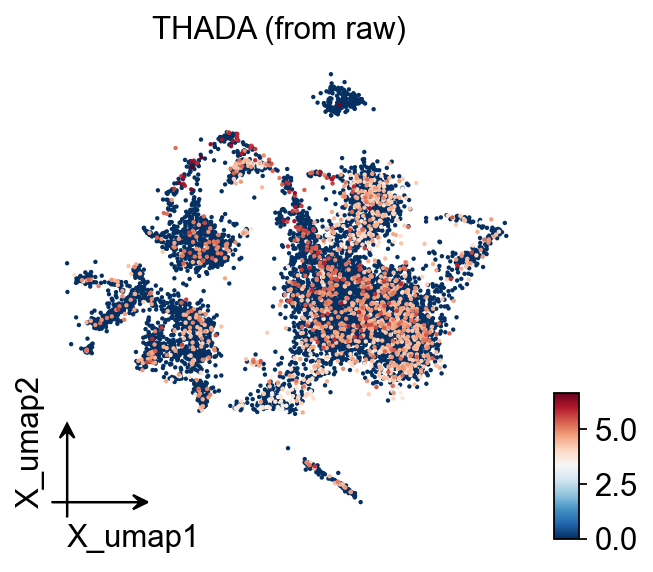

In [14]:
# Gene from raw (use_raw=True)
ov.pl.embedding(adata, basis='X_umap', color=non_hvg_genes[0],
                use_raw=True, frameon='small',
                title=f'{non_hvg_genes[0]} (from raw)')

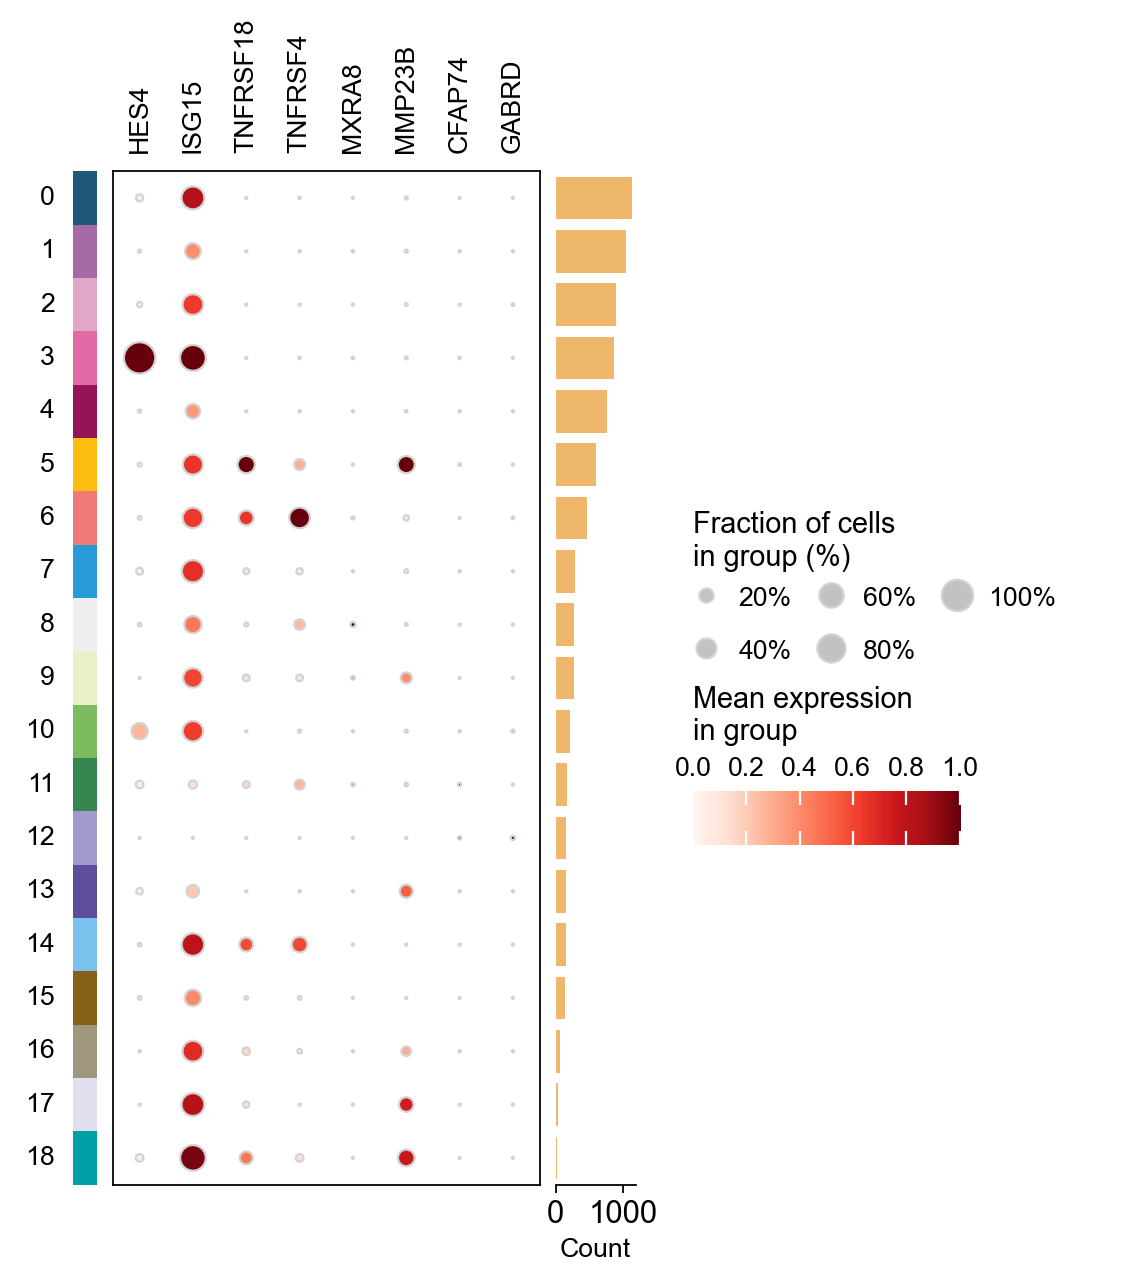

In [15]:
# Dotplot with HVG genes
ov.pl.dotplot(adata, list(adata.var_names[:8]),
              groupby='leiden', standard_scale='var')

<Axes: xlabel='leiden', ylabel='THADA'>

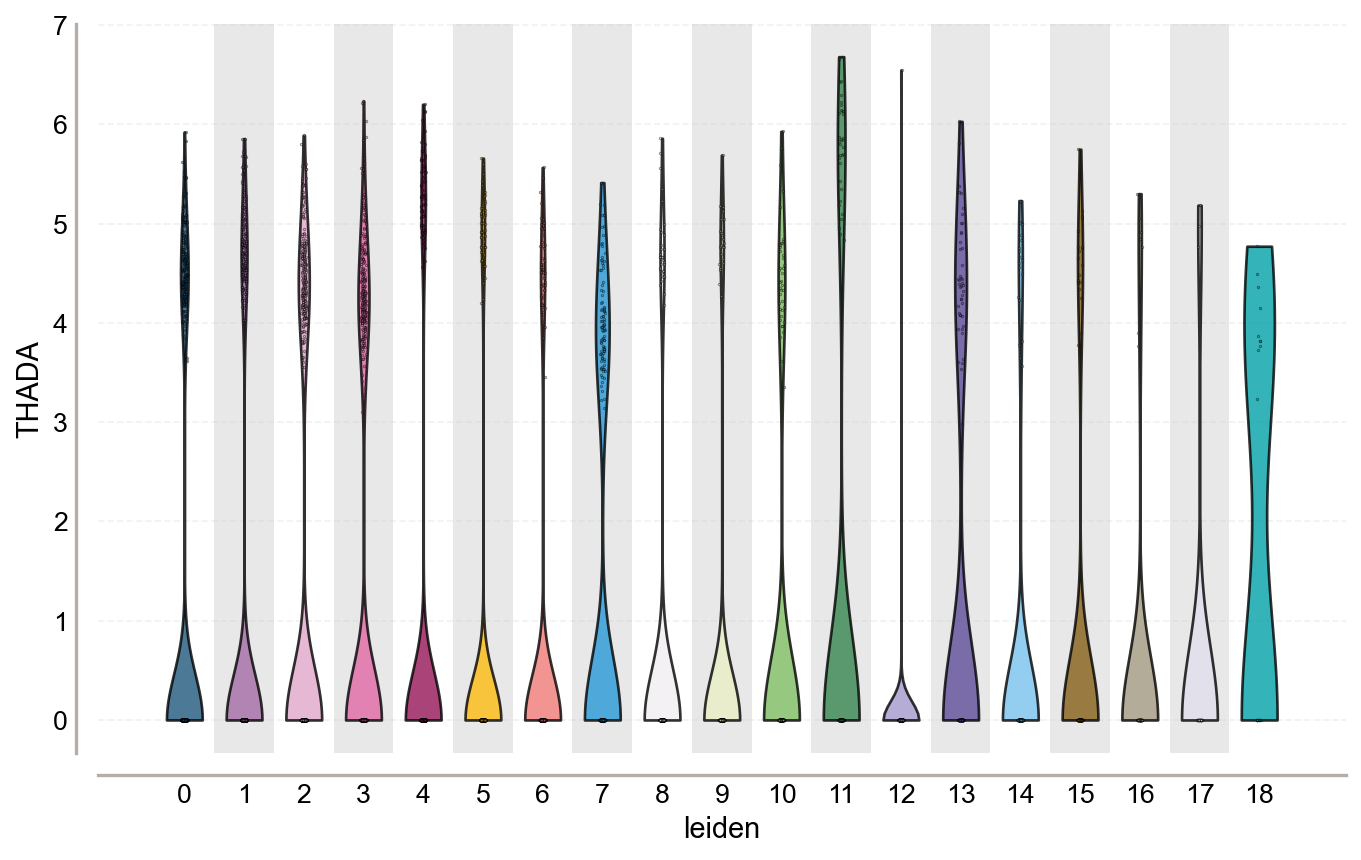

In [16]:
# Violin — gene from raw
ov.pl.violin(adata, keys=non_hvg_genes[0],
             groupby='leiden', use_raw=True)

## 8. Memory & Runtime Summary

  [final] RSS = 1089 MB


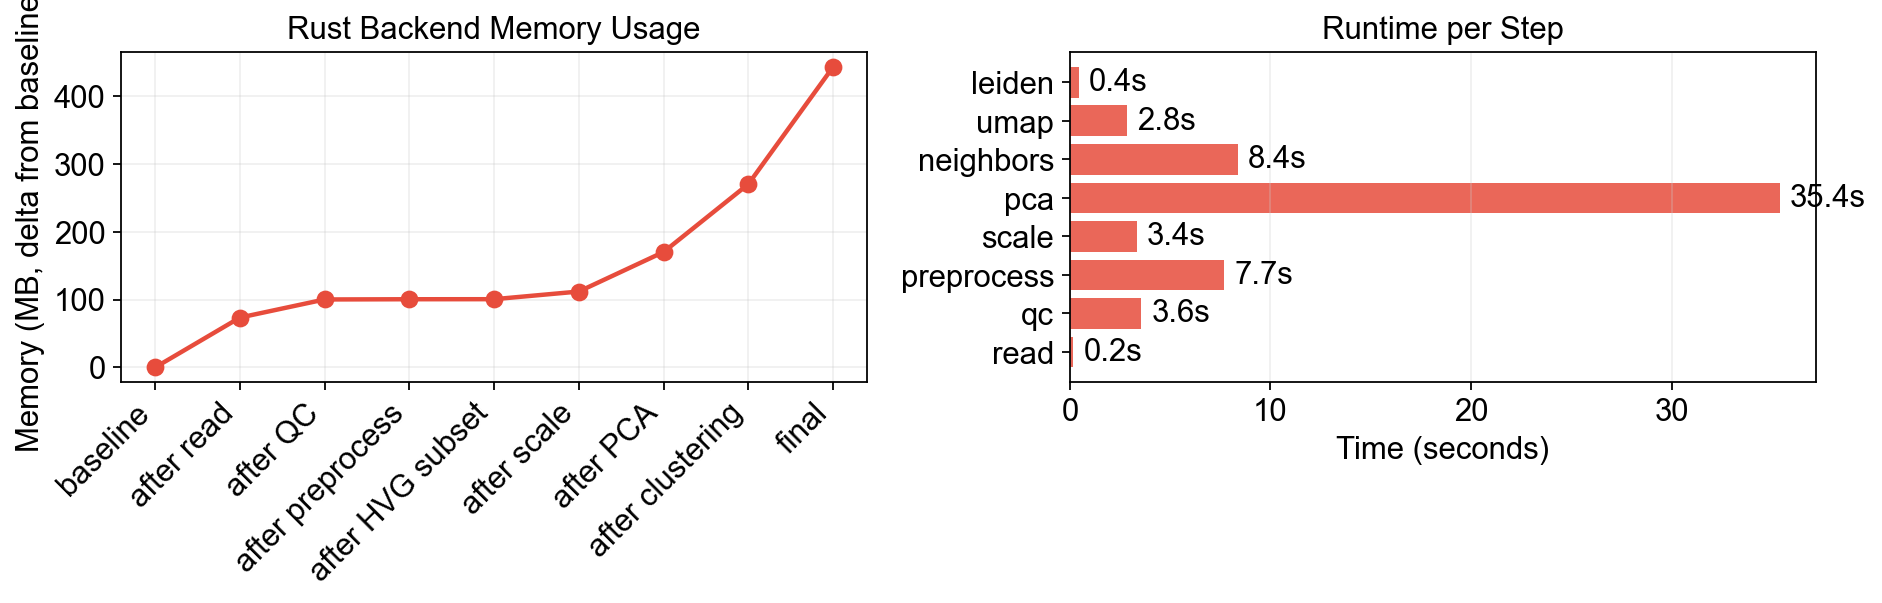

Peak memory (delta): 443 MB
Total time:          61.9s


In [17]:
snap('final')

df_mem = pd.DataFrame(mem_log)
df_mem['delta'] = df_mem['mem_mb'] - df_mem['mem_mb'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(len(df_mem)), df_mem['delta'], 'o-', color='#E74C3C', lw=2, ms=7)
ax.set_xticks(range(len(df_mem)))
ax.set_xticklabels(df_mem['step'], rotation=45, ha='right')
ax.set_ylabel('Memory (MB, delta from baseline)')
ax.set_title('Rust Backend Memory Usage')
ax.grid(True, alpha=0.3)

ax = axes[1]
steps = list(time_log.keys())
vals = [time_log[s] for s in steps]
ax.barh(steps, vals, color='#E74C3C', alpha=0.85)
ax.set_xlabel('Time (seconds)')
ax.set_title('Runtime per Step')
for i, v in enumerate(vals):
    ax.text(v + 0.5, i, f'{v:.1f}s', va='center')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"Peak memory (delta): {df_mem['delta'].max():.0f} MB")
print(f"Total time:          {sum(time_log.values()):.1f}s")

## 9. Comparison: Python vs Rust on PBMC 8k

Benchmark results from running the identical pipeline with `backend='python'` vs `backend='rust'`:

| Step | Python (MB) | Rust (MB) | Python (s) | Rust (s) |
|------|------------:|----------:|-----------:|---------:|
| read | 148 | **37** | 0.1 | 0.3 |
| qc | — | — | — | — |
| preprocess | 328 | **24** | 7.4 | 6.3 |
| hvg_subset | 450 | **24** | 0.0 | 0.0 |
| scale | 382 | **54** | 1.3 | 2.6 |
| pca | 846 | **33** | 1.1 | 53.5 |
| neighbors | 1195 | **33** | 14.9 | 0.1 |
| umap | 1500 | **34** | 7.1 | 4.5 |
| leiden | 1502 | **33** | 363.3 | 338.6 |
| **PEAK** | **1502** | **54** | | |
| **TOTAL** | | | **397** | **407** |

**Key observations:**
- Rust backend uses **27.8x less memory** (1502 MB → 54 MB peak)
- Total runtime is comparable (~400s, dominated by leiden clustering)
- Memory stays **flat** across the entire pipeline for Rust backend
- PCA is slower on Rust (53s) due to chunked randomized SVD, but this is independent of dataset size

## Architecture: Lazy Transform Chain

The full expression matrix is **never loaded into memory**:

```
X (HDF5 on disk, Rust I/O via anndata-rs)
  -> TransformedBackedArray (normalize: / per-cell size factors)
    -> TransformedBackedArray (log1p: on-the-fly)
      -> _SubsetBackedArray (HVG: 2000 gene columns)
        -> ScaledBackedArray (z-score: stores only mean/std vectors)
          -> Randomized SVD (chunked matrix products)
            -> X_pca (n_obs x 50, in-memory)
              -> Neighbors / UMAP / Leiden (operate on X_pca only)
```

Each transform node stores only a small descriptor (vector or flag), not matrices.
Data is computed on-the-fly during chunked reads.

**For 1M cells × 30k genes:** Python ~120 GB, Rust **~700 MB** (constant).

In [18]:
adata.close()